In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("SUPPORT VECTOR REGRESSION (SVR) - COMPREHENSIVE TUTORIAL")
print("="*80)

SUPPORT VECTOR REGRESSION (SVR) - COMPREHENSIVE TUTORIAL


In [3]:
# ============================================================================
# PART 1: UNDERSTANDING SVR CONCEPT
# ============================================================================
print("\n" + "="*80)
print("PART 1: UNDERSTANDING SUPPORT VECTOR REGRESSION")
print("="*80)

svr_concept = """
Support Vector Regression (SVR) Concept:
-----------------------------------------

1. BASIC IDEA:
   - SVR finds a function that deviates from actual targets by at most ε (epsilon)
   - It tries to fit the best line within a threshold (epsilon-tube)
   - Points outside this tube contribute to the error

2. KEY COMPONENTS:

   a) Epsilon (ε) - Insensitive Tube:
      - Defines a margin of tolerance where no penalty is given
      - Errors within ±ε are ignored (epsilon-insensitive loss)

   b) Support Vectors:
      - Data points that lie on or outside the epsilon tube
      - These are the critical points that define the regression function

   c) Kernel Trick:
      - Linear: For linear relationships
      - RBF (Radial Basis Function): For non-linear patterns (most common)
      - Polynomial: For polynomial relationships
      - Sigmoid: For neural network-like behavior

3. HYPERPARAMETERS:

   a) C (Regularization):
      - Controls trade-off between model complexity and training error
      - High C: Less tolerance for errors (may overfit)
      - Low C: More tolerance for errors (may underfit)

   b) Epsilon (ε):
      - Width of the epsilon-insensitive tube
      - Larger ε: Wider tube, more points inside (simpler model)
      - Smaller ε: Narrower tube, fewer points inside (complex model)

   c) Gamma (for RBF kernel):
      - Defines influence of single training example
      - High gamma: Close influence (may overfit)
      - Low gamma: Far influence (may underfit)

4. WHEN TO USE SVR:
   - Small to medium-sized datasets
   - Non-linear relationships (clearly as plus when you have to chose b/w Linear R and SVR)
   - Need for robust predictions with outliers
   - High-dimensional feature spaces
"""

print(svr_concept)


PART 1: UNDERSTANDING SUPPORT VECTOR REGRESSION

Support Vector Regression (SVR) Concept:
-----------------------------------------

1. BASIC IDEA:
   - SVR finds a function that deviates from actual targets by at most ε (epsilon)
   - It tries to fit the best line within a threshold (epsilon-tube)
   - Points outside this tube contribute to the error
   
2. KEY COMPONENTS:
   
   a) Epsilon (ε) - Insensitive Tube:
      - Defines a margin of tolerance where no penalty is given
      - Errors within ±ε are ignored (epsilon-insensitive loss)
      
   b) Support Vectors:
      - Data points that lie on or outside the epsilon tube
      - These are the critical points that define the regression function
      
   c) Kernel Trick:
      - Linear: For linear relationships
      - RBF (Radial Basis Function): For non-linear patterns (most common)
      - Polynomial: For polynomial relationships
      - Sigmoid: For neural network-like behavior

3. HYPERPARAMETERS:
   
   a) C (Regularizati

In [4]:
# ============================================================================
# PART 2: LOAD AND EXPLORE DATA
# ============================================================================
print("\n" + "="*80)
print("PART 2: DATA LOADING AND EXPLORATION")
print("="*80)

# Generate realistic housing data with non-linear relationships
print("\nGenerating California-style housing dataset...")

np.random.seed(42)
n_samples = 5000

# Generate features
df = pd.DataFrame({
    'MedInc': np.random.gamma(4, 2, n_samples),  # Median income
    'HouseAge': np.random.uniform(1, 52, n_samples),  # House age
    'AveRooms': np.random.gamma(6, 1, n_samples),  # Average rooms
    'AveBedrms': np.random.gamma(1.1, 0.9, n_samples),  # Average bedrooms
    'Population': np.random.lognormal(6, 1.2, n_samples),  # Population
    'AveOccup': np.random.gamma(3, 1, n_samples),  # Average occupancy
    'Latitude': np.random.uniform(32.5, 42, n_samples),  # Latitude
    'Longitude': np.random.uniform(-124.35, -114.31, n_samples)  # Longitude
})

# Create target with non-linear relationships
df['target'] = (
    2.5 * df['MedInc'] +  # Strong linear relationship
    0.05 * df['HouseAge'] -  # Slight positive effect
    0.3 * (df['HouseAge'] ** 2) / 100 +  # Non-linear age effect
    0.15 * df['AveRooms'] +  # Room effect
    0.001 * df['Population'] / 100 -  # Small population effect
    0.05 * df['AveOccup'] +  # Occupancy effect
    np.sin(df['Latitude'] / 10) * 0.5 +  # Geographic non-linearity
    np.random.normal(0, 0.5, n_samples)  # Noise
)

# Ensure positive target values
df['target'] = np.clip(df['target'], 0.5, None)

print("\nDataset Description:")
print("California Housing-style dataset with 8 features predicting median house values")
print("Features: Income, House Age, Rooms, Bedrooms, Population, Occupancy, Lat/Long")
print("Target: Median house value (in $100,000s)")

print("\nDataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nStatistical Summary:")
print(df.describe())

print("\nTarget Variable (Median House Value) Distribution:")
print(f"Mean: ${df['target'].mean():.2f} (in $100,000s)")
print(f"Median: ${df['target'].median():.2f} (in $100,000s)")
print(f"Std Dev: ${df['target'].std():.2f} (in $100,000s)")


PART 2: DATA LOADING AND EXPLORATION

Generating California-style housing dataset...

Dataset Description:
California Housing-style dataset with 8 features predicting median house values
Features: Income, House Age, Rooms, Bedrooms, Population, Occupancy, Lat/Long
Target: Median house value (in $100,000s)

Dataset Shape: (5000, 9)

First few rows:
      MedInc   HouseAge  AveRooms  AveBedrms   Population  AveOccup  \
0   9.404828  22.696991  6.069549   0.839686   988.429862  4.226803   
1   6.816464  39.530228  4.145284   0.562724    88.376470  3.252006   
2   6.472649  31.858646  5.029036   0.257529   174.643399  3.051567   
3   6.472707  36.120094  6.549298   1.812233   299.374838  2.090959   
4  15.196220  15.398644  3.907760   0.538396  1107.484133  1.630173   

    Latitude   Longitude     target  
0  41.021852 -116.473744  23.471083  
1  37.910214 -122.129623  15.072200  
2  37.324793 -117.630765  14.618299  
3  37.339179 -114.608932  14.339472  
4  41.164781 -117.564277  39.205

In [5]:
# ============================================================================
# PART 3: DATA PREPARATION
# ============================================================================
print("\n" + "="*80)
print("PART 3: DATA PREPARATION")
print("="*80)

X = df.drop('target', axis=1)
y = df['target']

print(f"\nUsing {len(df)} samples")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Feature Scaling (CRITICAL for SVR!)
print("\nScaling features (essential for SVR)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled to mean=0, std=1")


PART 3: DATA PREPARATION

Using 5000 samples
Features shape: (5000, 8)
Target shape: (5000,)

Train set size: 4000
Test set size: 1000

Scaling features (essential for SVR)...
✓ Features scaled to mean=0, std=1


In [6]:
# ============================================================================
# PART 4: SVR WITH DIFFERENT KERNELS
# ============================================================================
print("\n" + "="*80)
print("PART 4: COMPARING DIFFERENT SVR KERNELS")
print("="*80)

kernels = ['linear', 'rbf', 'poly']
svr_models = {}
results = []

for kernel in kernels:
    print(f"\n{'='*60}")
    print(f"Training SVR with {kernel.upper()} kernel...")
    print(f"{'='*60}")

    if kernel == 'poly':
        svr = SVR(kernel=kernel, degree=3, C=1.0, epsilon=0.1)
    else:
        svr = SVR(kernel=kernel, C=1.0, epsilon=0.1)

    # Train
    svr.fit(X_train_scaled, y_train)

    # Predict
    y_pred_train = svr.predict(X_train_scaled)
    y_pred_test = svr.predict(X_test_scaled)

    # Evaluate
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)

    svr_models[kernel] = svr

    results.append({
        'Kernel': kernel,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Support Vectors': len(svr.support_)
    })

    print(f"\nResults for {kernel.upper()} kernel:")
    print(f"  Train R² Score: {train_r2:.4f}")
    print(f"  Test R² Score: {test_r2:.4f}")
    print(f"  Train RMSE: {train_rmse:.4f}")
    print(f"  Test RMSE: {test_rmse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  Number of Support Vectors: {len(svr.support_)}/{len(X_train)}")

# Display comparison table
print("\n" + "="*80)
print("KERNEL COMPARISON SUMMARY")
print("="*80)
results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))


PART 4: COMPARING DIFFERENT SVR KERNELS

Training SVR with LINEAR kernel...

Results for LINEAR kernel:
  Train R² Score: 0.9938
  Test R² Score: 0.9948
  Train RMSE: 0.7950
  Test RMSE: 0.7671
  Test MAE: 0.6105
  Number of Support Vectors: 3645/4000

Training SVR with RBF kernel...

Results for RBF kernel:
  Train R² Score: 0.9374
  Test R² Score: 0.9377
  Train RMSE: 2.5174
  Test RMSE: 2.6419
  Test MAE: 1.0991
  Number of Support Vectors: 3578/4000

Training SVR with POLY kernel...

Results for POLY kernel:
  Train R² Score: 0.7904
  Test R² Score: 0.8172
  Train RMSE: 4.6072
  Test RMSE: 4.5265
  Test MAE: 3.0069
  Number of Support Vectors: 3865/4000

KERNEL COMPARISON SUMMARY

 Kernel  Train R²  Test R²  Train RMSE  Test RMSE  Test MAE  Support Vectors
linear  0.993760 0.994751    0.794975   0.767106  0.610454             3645
   rbf  0.937423 0.937746    2.517393   2.641869  1.099094             3578
  poly  0.790401 0.817245    4.607225   4.526496  3.006930             3865


In [8]:
# ============================================================================
# PART 5: HYPERPARAMETER TUNING (RBF KERNEL)
# ============================================================================
print("\n" + "="*80)
print("PART 5: HYPERPARAMETER TUNING FOR RBF KERNEL")
print("="*80)

print("\nPerforming Grid Search for optimal hyperparameters...")
print("This may take a few minutes...\n")

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

# Grid search with cross-validation
svr_rbf = SVR(kernel='rbf')
grid_search = GridSearchCV(
    svr_rbf,
    param_grid,
    cv=2,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R² Score: {grid_search.best_score_:.4f}")

# Train with best parameters
best_svr = grid_search.best_estimator_
y_pred_test_best = best_svr.predict(X_test_scaled)

print("\nPerformance with Optimized Hyperparameters:")
print(f"  Test R² Score: {r2_score(y_test, y_pred_test_best):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_best)):.4f}")
print(f"  Test MAE: {mean_absolute_error(y_test, y_pred_test_best):.4f}")
print(f"  Number of Support Vectors: {len(best_svr.support_)}/{len(X_train)}")


PART 5: HYPERPARAMETER TUNING FOR RBF KERNEL

Performing Grid Search for optimal hyperparameters...
This may take a few minutes...

Fitting 2 folds for each of 60 candidates, totalling 120 fits

GRID SEARCH RESULTS

Best Parameters: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01}
Best Cross-Validation R² Score: 0.9960

Performance with Optimized Hyperparameters:
  Test R² Score: 0.9974
  Test RMSE: 0.5416
  Test MAE: 0.4334
  Number of Support Vectors: 3379/4000


In [9]:
# ============================================================================
# PART 6: ANALYZING SUPPORT VECTORS
# ============================================================================
print("\n" + "="*80)
print("PART 6: SUPPORT VECTOR ANALYSIS")
print("="*80)

support_vector_ratio = len(best_svr.support_) / len(X_train) * 100

print(f"\nSupport Vector Statistics:")
print(f"  Total training samples: {len(X_train)}")
print(f"  Number of support vectors: {len(best_svr.support_)}")
print(f"  Percentage of support vectors: {support_vector_ratio:.2f}%")

print("\nInterpretation:")
if support_vector_ratio < 30:
    print("  → Low percentage suggests the model found a good fit with few critical points")
elif support_vector_ratio < 60:
    print("  → Moderate percentage indicates a reasonably complex decision boundary")
else:
    print("  → High percentage may suggest the data is complex or parameters need tuning")


PART 6: SUPPORT VECTOR ANALYSIS

Support Vector Statistics:
  Total training samples: 4000
  Number of support vectors: 3379
  Percentage of support vectors: 84.47%

Interpretation:
  → High percentage may suggest the data is complex or parameters need tuning



PART 7: GENERATING VISUALIZATIONS

✓ Visualization saved as 'svr_analysis.png'


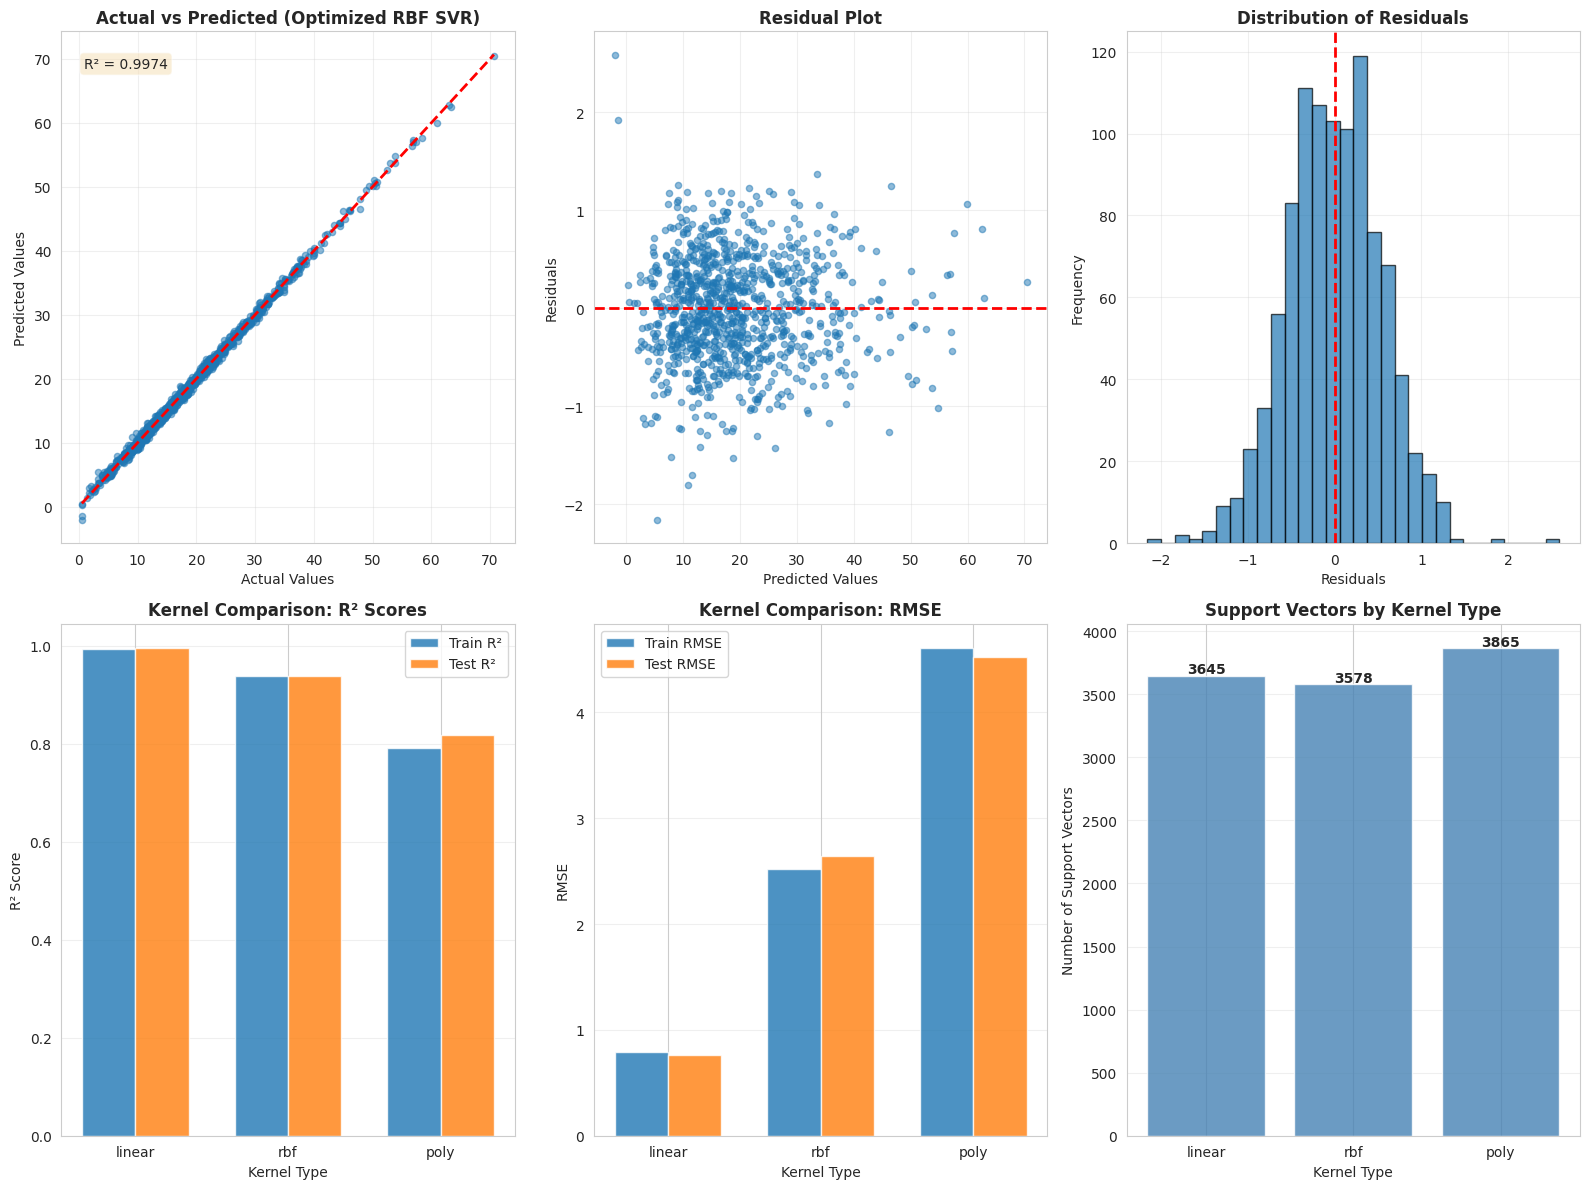

In [14]:
# ============================================================================
# PART 7: VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("PART 7: GENERATING VISUALIZATIONS")
print("="*80)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 1. Actual vs Predicted (Best Model)
ax1 = plt.subplot(2, 3, 1)
plt.scatter(y_test, y_pred_test_best, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values', fontsize=10)
plt.ylabel('Predicted Values', fontsize=10)
plt.title('Actual vs Predicted (Optimized RBF SVR)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add R² score to plot
r2 = r2_score(y_test, y_pred_test_best)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax1.transAxes,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residual Plot
ax2 = plt.subplot(2, 3, 2)
residuals = y_test - y_pred_test_best
plt.scatter(y_pred_test_best, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values', fontsize=10)
plt.ylabel('Residuals', fontsize=10)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 3. Residual Distribution
ax3 = plt.subplot(2, 3, 3)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Distribution of Residuals', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)

# 4. Kernel Comparison - R² Scores
ax4 = plt.subplot(2, 3, 4)
kernels_plot = results_df['Kernel']
test_r2_plot = results_df['Test R²']
train_r2_plot = results_df['Train R²']

x_pos = np.arange(len(kernels_plot))
width = 0.35

plt.bar(x_pos - width/2, train_r2_plot, width, label='Train R²', alpha=0.8)
plt.bar(x_pos + width/2, test_r2_plot, width, label='Test R²', alpha=0.8)
plt.xlabel('Kernel Type', fontsize=10)
plt.ylabel('R² Score', fontsize=10)
plt.title('Kernel Comparison: R² Scores', fontsize=12, fontweight='bold')
plt.xticks(x_pos, kernels_plot)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 5. Kernel Comparison - RMSE
ax5 = plt.subplot(2, 3, 5)
test_rmse_plot = results_df['Test RMSE']
train_rmse_plot = results_df['Train RMSE']

plt.bar(x_pos - width/2, train_rmse_plot, width, label='Train RMSE', alpha=0.8)
plt.bar(x_pos + width/2, test_rmse_plot, width, label='Test RMSE', alpha=0.8)
plt.xlabel('Kernel Type', fontsize=10)
plt.ylabel('RMSE', fontsize=10)
plt.title('Kernel Comparison: RMSE', fontsize=12, fontweight='bold')
plt.xticks(x_pos, kernels_plot)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 6. Support Vectors Comparison
ax6 = plt.subplot(2, 3, 6)
sv_counts = results_df['Support Vectors']
plt.bar(kernels_plot, sv_counts, alpha=0.8, color='steelblue')
plt.xlabel('Kernel Type', fontsize=10)
plt.ylabel('Number of Support Vectors', fontsize=10)
plt.title('Support Vectors by Kernel Type', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, v in enumerate(sv_counts):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('svr_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'svr_analysis.png'")



PART 8: FEATURE IMPORTANCE ANALYSIS

Calculating permutation feature importance...

Feature Importance Ranking:
   Feature  Importance      Std
    MedInc    1.952734 0.059606
  HouseAge    0.052287 0.002015
  AveRooms    0.002315 0.000089
  Latitude    0.000241 0.000036
  AveOccup    0.000141 0.000041
 Longitude   -0.000018 0.000021
Population   -0.000033 0.000020
 AveBedrms   -0.000048 0.000017

✓ Feature importance plot saved as 'svr_feature_importance.png'


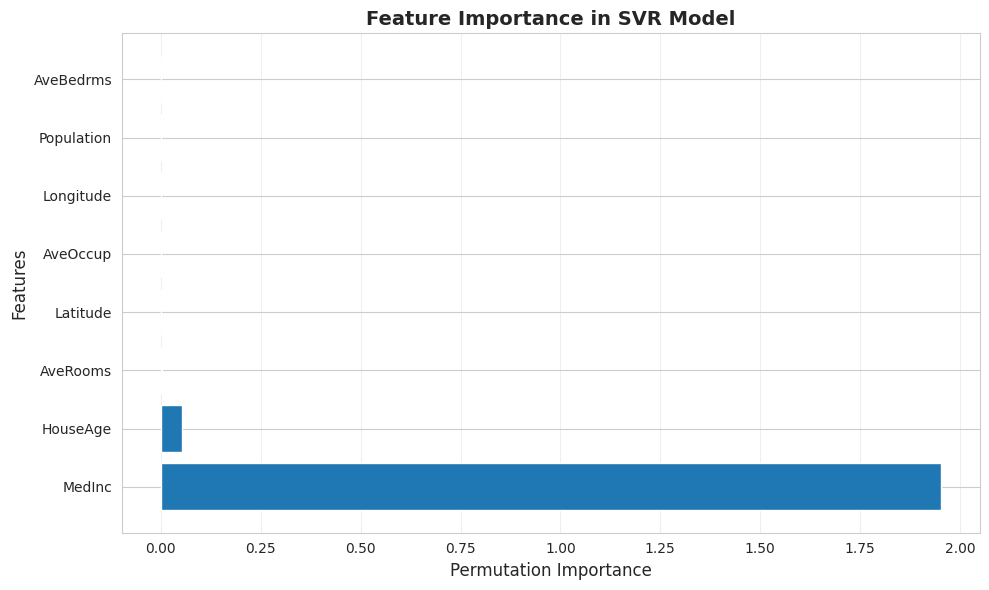

In [15]:
# ============================================================================
# PART 8: FEATURE IMPORTANCE (Using Permutation)
# ============================================================================
print("\n" + "="*80)
print("PART 8: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

from sklearn.inspection import permutation_importance

print("\nCalculating permutation feature importance...")
perm_importance = permutation_importance(
    best_svr, X_test_scaled, y_test, n_repeats=10, random_state=42
)

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Permutation Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance in SVR Model', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('/svr_feature_importance.png', dpi=300, bbox_inches='tight')
print("\n✓ Feature importance plot saved as 'svr_feature_importance.png'")


In [ ]:
# SVC - NLP Sentiment classification

In [1]:
"""
TF-IDF (Term Frequency - Inverse Document Frequency) Explained
==============================================================

TF-IDF is a numerical statistic that reflects how important a word is
to a document in a collection (corpus).

Key Intuition:
- Words that appear frequently in ONE document but rarely in others are important
- Common words like "the", "is", "a" appear everywhere → low importance
- Unique/specific words distinguish documents → high importance

Formula:
    TF-IDF = TF × IDF

Where:
    TF (Term Frequency) = (Count of term in document) / (Total terms in document)
    IDF (Inverse Document Frequency) = log(Total documents / Documents containing term)
"""

import math
from collections import Counter

# Simple corpus of documents
documents = [
    "The cat sat on the mat",
    "The dog chased the cat",
    "The bird flew over the mat"
]

In [2]:
print("=" * 60)
print("BONUS: Using scikit-learn's TfidfVectorizer")
print("=" * 60)

try:
    from sklearn.feature_extraction.text import TfidfVectorizer

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(documents)

    feature_names = vectorizer.get_feature_names_out()

    print("\nTF-IDF Matrix (rows=documents, columns=words):")
    print(f"Features: {list(feature_names)}\n")

    for i, doc in enumerate(documents):
        print(f"Doc {i+1}: {tfidf_matrix[i].toarray().round(3)[0]}")

    print("\n💡 sklearn uses a slightly different formula (with smoothing)")
    print("   but the concept remains the same!")

except ImportError:
    print("sklearn not installed - skipping this section")

BONUS: Using scikit-learn's TfidfVectorizer

TF-IDF Matrix (rows=documents, columns=words):
Features: ['bird', 'cat', 'chased', 'dog', 'flew', 'mat', 'on', 'over', 'sat', 'the']

Doc 1: [0.    0.356 0.    0.    0.    0.356 0.469 0.    0.469 0.554]
Doc 2: [0.    0.382 0.502 0.502 0.    0.    0.    0.    0.    0.593]
Doc 3: [0.448 0.    0.    0.    0.448 0.341 0.    0.448 0.    0.53 ]

💡 sklearn uses a slightly different formula (with smoothing)
   but the concept remains the same!


In [ ]:
The cat sat on the mat
[0.    0.356 0.    0.    0.    0.356 0.469 0.    0.469 0.554]

In [ ]:
# TF-IDF Vectorization converts raw text into numerical features where each word's importance is weighted by its frequency in the document vs. across all documents
# SVM with Linear Kernel finds the optimal hyperplane that separates positive from negative reviews in this high-dimensional feature space
# Feature Weights show which words push the classification toward positive (high weight) or negative (low weight)

In [3]:
"""
Text Classification using TF-IDF + SVM
======================================

This example demonstrates how to:
1. Convert text sentences into TF-IDF feature vectors
2. Train an SVM classifier on these features
3. Classify new sentences

Use Case: Sentiment Classification (Positive vs Negative reviews)
"""

'\nText Classification using TF-IDF + SVM\n======================================\n\nThis example demonstrates how to:\n1. Convert text sentences into TF-IDF feature vectors\n2. Train an SVM classifier on these features\n3. Classify new sentences\n\nUse Case: Sentiment Classification (Positive vs Negative reviews)\n'

In [4]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ============================================================
# STEP 1: Prepare Training Data
# ============================================================
print("=" * 65)
print("STEP 1: TRAINING DATA (Sentiment Classification)")
print("=" * 65)

# Sample dataset: Movie/Product reviews (expanded for better training)
sentences = [
    # Positive reviews (label = 1)
    "This movie was absolutely fantastic and amazing",
    "I loved every moment of this film",
    "Brilliant performance by all actors",
    "Best movie I have seen this year",
    "Wonderful story and great direction",
    "Highly recommended, truly enjoyable experience",
    "The plot was engaging and exciting",
    "A masterpiece of cinema",
    "Excellent acting and beautiful cinematography",
    "I was thoroughly impressed and entertained",
    "Outstanding film with perfect execution",
    "Incredible story that moved me to tears",
    "Superb quality and great value",
    "Very satisfied with this purchase",
    "Exceptional product exceeded expectations",
    "Love this so much will buy again",
    "Perfect in every way highly recommend",
    "Amazing quality fantastic service",
    "Great experience would definitely recommend",
    "Wonderful product very happy customer",

    # Negative reviews (label = 0)
    "This movie was terrible and boring",
    "Complete waste of time and money",
    "Worst film I have ever watched",
    "The acting was awful and unconvincing",
    "I hated every minute of this disaster",
    "Poorly written script with bad direction",
    "Extremely disappointing and frustrating",
    "The plot made no sense at all",
    "Avoid this movie at all costs",
    "A complete failure in every way",
    "Horrible experience never buying again",
    "Terrible quality broke after one use",
    "Very disappointed with this purchase",
    "Waste of money do not buy",
    "Awful product terrible customer service",
    "Worst purchase I have ever made",
    "Completely useless and frustrating",
    "Poor quality not worth the price",
    "Regret buying this total disappointment",
    "Broken on arrival terrible experience"
]

# Labels: 1 = Positive, 0 = Negative
labels = [1] * 20 + [0] * 20  # First 20 positive, last 20 negative

print("\n📗 POSITIVE Examples:")
for i, sent in enumerate(sentences[:5]):
    print(f"   {i+1}. \"{sent}\"")
print("   ...")

print("\n📕 NEGATIVE Examples:")
for i, sent in enumerate(sentences[20:25]):  # Fixed: start from index 20
    print(f"   {i+1}. \"{sent}\"")
print("   ...")

STEP 1: TRAINING DATA (Sentiment Classification)

📗 POSITIVE Examples:
   1. "This movie was absolutely fantastic and amazing"
   2. "I loved every moment of this film"
   3. "Brilliant performance by all actors"
   4. "Best movie I have seen this year"
   5. "Wonderful story and great direction"
   ...

📕 NEGATIVE Examples:
   1. "This movie was terrible and boring"
   2. "Complete waste of time and money"
   3. "Worst film I have ever watched"
   4. "The acting was awful and unconvincing"
   5. "I hated every minute of this disaster"
   ...


In [6]:
# ============================================================
# STEP 2: Convert Text to TF-IDF Features
# ============================================================
print("\n" + "=" * 65)
print("STEP 2: CONVERT TEXT TO TF-IDF FEATURES")
print("=" * 65)

# Create TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,           # Convert to lowercase
    stop_words='english',     # Remove common words (the, is, a, etc.)
    max_features=100,         # Keep top 100 features
    ngram_range=(1, 2)        # Use unigrams and bigrams
)

# Fit and transform the sentences
X_tfidf = tfidf_vectorizer.fit_transform(sentences)
y = np.array(labels)

print(f"\n📊 TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"   → {X_tfidf.shape[0]} sentences converted to {X_tfidf.shape[1]} features")

# Show the vocabulary (features)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n📝 Sample Features (words/phrases learned):")
print(f"   {list(feature_names[:15])}...")

# Show TF-IDF values for first sentence
print(f"\n🔍 TF-IDF values for: \"{sentences[0]}\"")
first_sentence_tfidf = X_tfidf[0].toarray()[0]
non_zero_indices = np.where(first_sentence_tfidf > 0)[0]
for idx in non_zero_indices:
    print(f"   '{feature_names[idx]}': {first_sentence_tfidf[idx]:.4f}")


STEP 2: CONVERT TEXT TO TF-IDF FEATURES

📊 TF-IDF Matrix Shape: (40, 100)
   → 40 sentences converted to 100 features

📝 Sample Features (words/phrases learned):
   ['absolutely fantastic', 'acting', 'acting awful', 'acting beautiful', 'amazing', 'amazing quality', 'arrival', 'arrival terrible', 'avoid', 'avoid movie', 'awful', 'awful unconvincing', 'bad', 'bad direction', 'beautiful']...

🔍 TF-IDF values for: "This movie was absolutely fantastic and amazing"
   'absolutely fantastic': 0.4872
   'amazing': 0.4381
   'fantastic': 0.4381
   'fantastic amazing': 0.4872
   'movie': 0.3762


In [7]:
# ============================================================
# STEP 3: Train-Test Split
# ============================================================
print("\n" + "=" * 65)
print("STEP 3: SPLIT DATA INTO TRAIN AND TEST SETS")
print("=" * 65)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n📂 Training set: {X_train.shape[0]} samples")
print(f"📂 Test set: {X_test.shape[0]} samples")

# ============================================================
# STEP 4: Train SVM Classifier
# ============================================================
print("\n" + "=" * 65)
print("STEP 4: TRAIN SVM CLASSIFIER")
print("=" * 65)

# Create and train SVM with linear kernel (works well for text)
svm_classifier = SVC(
    kernel='linear',      # Linear kernel is effective for text classification
    C=1.0,                # Regularization parameter
    probability=True      # Enable probability estimates
)

svm_classifier.fit(X_train, y_train)
print("\n✅ SVM Classifier trained successfully!")

# Show the most important features (words) for each class
print("\n🎯 MOST IMPORTANT WORDS FOR CLASSIFICATION:")
print("-" * 50)

# Get feature weights from SVM
coef = svm_classifier.coef_
if hasattr(coef, 'toarray'):
    feature_weights = coef.toarray().flatten()
else:
    feature_weights = np.array(coef).flatten()

# Top positive indicators (high weight = positive sentiment)
top_positive_idx = np.argsort(feature_weights)[-10:][::-1]
print("\n   Words indicating POSITIVE sentiment:")
for idx in top_positive_idx:
    weight = float(feature_weights[idx])
    print(f"      '{feature_names[idx]}': weight = {weight:.4f}")

# Top negative indicators (low weight = negative sentiment)
top_negative_idx = np.argsort(feature_weights)[:10]
print("\n   Words indicating NEGATIVE sentiment:")
for idx in top_negative_idx:
    weight = float(feature_weights[idx])
    print(f"      '{feature_names[idx]}': weight = {weight:.4f}")



STEP 3: SPLIT DATA INTO TRAIN AND TEST SETS

📂 Training set: 28 samples
📂 Test set: 12 samples

STEP 4: TRAIN SVM CLASSIFIER

✅ SVM Classifier trained successfully!

🎯 MOST IMPORTANT WORDS FOR CLASSIFICATION:
--------------------------------------------------

   Words indicating POSITIVE sentiment:
      'cinema': weight = 0.8844
      'great': weight = 0.8660
      'best movie': weight = 0.7915
      'perfect': weight = 0.7549
      'love': weight = 0.7436
      'highly': weight = 0.7329
      'great value': weight = 0.6621
      'wonderful': weight = 0.6164
      'product': weight = 0.5261
      'execution': weight = 0.5115

   Words indicating NEGATIVE sentiment:
      'worst': weight = -1.2585
      'terrible': weight = -0.9862
      'money': weight = -0.7477
      'waste': weight = -0.7477
      'boring': weight = -0.6566
      'bad': weight = -0.5967
      'buying total': weight = -0.5967
      'bad direction': weight = -0.5967
      'completely useless': weight = -0.5967
     

In [8]:
# ============================================================
# STEP 5: Evaluate on Test Set
# ============================================================
print("\n" + "=" * 65)
print("STEP 5: EVALUATE MODEL PERFORMANCE")
print("=" * 65)

y_pred = svm_classifier.predict(X_test)

print("\n📊 Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

print("📊 Confusion Matrix:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)
print(f"                 Predicted")
print(f"              Neg    Pos")
print(f"   Actual Neg  {cm[0][0]}      {cm[0][1]}")
print(f"          Pos  {cm[1][0]}      {cm[1][1]}")

# ============================================================
# STEP 6: Classify New Sentences
# ============================================================
print("\n" + "=" * 65)
print("STEP 6: CLASSIFY NEW SENTENCES")
print("=" * 65)

# New sentences to classify
new_sentences = [
    "This was an amazing experience, loved it!",
    "Terrible product, complete waste of money",
    "The quality exceeded my expectations",
    "I regret buying this, very disappointing",
    "Absolutely brilliant, highly recommend",
    "Not worth watching, boring and slow",
    "Good value for the price",
    "Poor customer service, never again"
]

print("\n🆕 Classifying new sentences:\n")

# Transform new sentences using the SAME vectorizer
X_new = tfidf_vectorizer.transform(new_sentences)

# Predict
predictions = svm_classifier.predict(X_new)
probabilities = svm_classifier.predict_proba(X_new)

for i, sentence in enumerate(new_sentences):
    sentiment = "POSITIVE 👍" if predictions[i] == 1 else "NEGATIVE 👎"
    confidence = max(probabilities[i]) * 100
    print(f"   \"{sentence}\"")
    print(f"   → {sentiment} (Confidence: {confidence:.1f}%)\n")

# ============================================================
# SUMMARY: The Complete Pipeline
# ============================================================
print("=" * 65)
print("SUMMARY: TF-IDF + SVM CLASSIFICATION PIPELINE")
print("=" * 65)


STEP 5: EVALUATE MODEL PERFORMANCE

📊 Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.60      0.50      0.55         6
    Positive       0.57      0.67      0.62         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12

📊 Confusion Matrix:
--------------------------------------------------
                 Predicted
              Neg    Pos
   Actual Neg  3      3
          Pos  2      4

STEP 6: CLASSIFY NEW SENTENCES

🆕 Classifying new sentences:

   "This was an amazing experience, loved it!"
   → POSITIVE 👍 (Confidence: 52.3%)

   "Terrible product, complete waste of money"
   → NEGATIVE 👎 (Confidence: 68.6%)

   "The quality exceeded my expectations"
   → POSITIVE 👍 (Confidence: 58.0%)

   "I regret buying this, very disappointing"
   → NEGATIVE 👎 (Confidence: 54.8